# TorchSig Models v1.0 in 10 minutes

**Goal:** go from synthetic RF data to training, evaluation, inference, and the ideas needed for `solve_challenge.ipynb`. This notebook uses the repository's 2-D EfficientNet-B0 for the end-to-end workflow and the released 1-D XCiT for the challenge.

> **Presenter (0:00–0:40):** TorchSig generates labeled RF examples; TorchSig Models supplies model architectures and reusable training/evaluation helpers. IQ is a complex time series: every sample has in-phase and quadrature components, which together preserve amplitude and phase. A spectrogram divides that stream into short windows and shows where energy occurs in time and frequency. That representation is often intuitive for a convolutional image model, but discards information that may matter for modulation recognition. EfficientNet consumes the spectrogram; XCiT consumes I and Q directly. Today the point is the workflow, not an architecture contest. The notebook is meant to be pre-executed—during the talk, explain outputs without waiting for generation or training.

## 1. Install and import

This notebook works in Google Colab or from a local clone. In Colab, run the next cell once; it installs the v1.0.0 tag directly from GitHub because TorchSig Models is not yet published on PyPI. Colab may ask you to restart the runtime after installation. Locally, create an environment with `python -m pip install -r requirements.txt`; when developing the repository itself, use `python -m pip install -e ..` instead.

> The generated datasets and checkpoints are written under `runs/v1_tutorial`. Colab's filesystem is temporary, so download checkpoints you want to keep before the runtime disconnects.

In [1]:
# Run this cell only in Google Colab. A local clone should use requirements.txt.
import sys
import subprocess

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    subprocess.check_call([
        sys.executable, '-m', 'pip', 'install', '-q',
        'git+https://github.com/TorchDSP/torchsig-models.git@v1.0.0',
        'matplotlib>=3.7', 'scipy>=1.10',
    ])
else:
    print('Local runtime detected; using the current environment.')

Local runtime detected; using the current environment.


In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from scipy import signal

import torchsig_models
from torchsig.datasets.datasets import StaticTorchSigDataset, TorchSigDatasetConfig
from torchsig.transforms.transforms import ComplexTo2D
from torchsig.utils.defaults import TorchSigDefaults
from torchsig.utils.file_handlers import SigMFReader
from torchsig_models.models import XCiTClassifier
from torchsig_models.models.spectrogram_models.efficientnet.efficientnet_inference import efficientnet_inference
from torchsig_models.models.spectrogram_models.efficientnet.efficientnet_train import train_efficientnet_2d
from torchsig_models.utils.training import evaluate_classifier, set_deterministic

assert torchsig_models.__version__ == '1.0.0'
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
RUN_TRAINING = False  # Set True when you want to generate data and train.
RUNS = Path('runs/v1_tutorial')
set_deterministic(2026)
print(f'TorchSig Models {torchsig_models.__version__}; device={DEVICE}')

TorchSig Models 1.0.0; device=cuda


### The same signal, two representations

The plot below is deliberately independent of TorchSig dataset generation, so it renders quickly even on a fresh Colab CPU. The top panel shows the real and imaginary IQ channels. The bottom panel shows the spectrogram given to the 2-D EfficientNet. XCiT uses the two IQ traces directly and can retain phase information; EfficientNet sees time-frequency energy, making a chirp's rising frequency visually explicit.

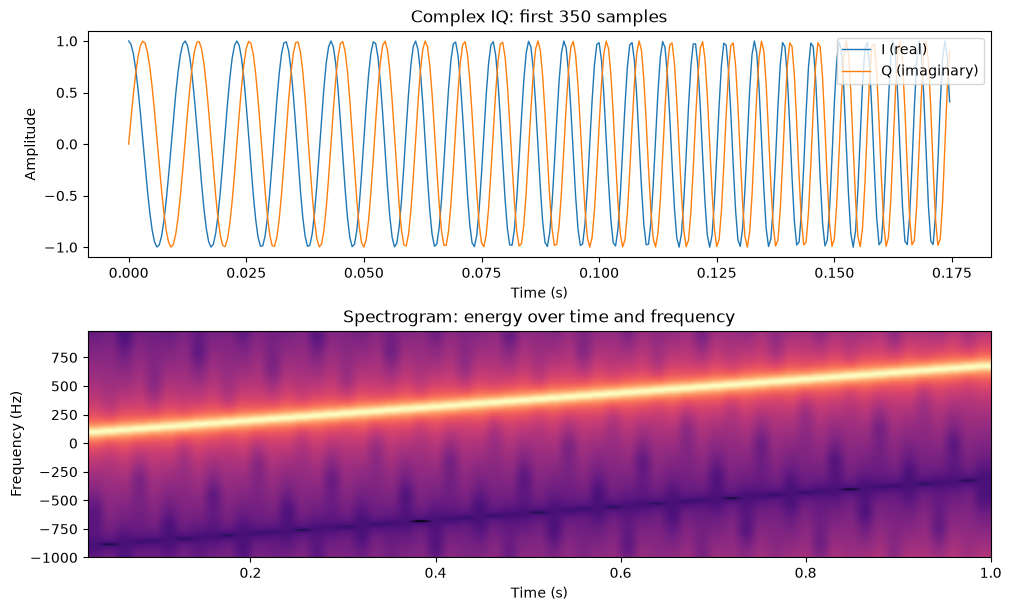

In [3]:
sample_rate = 2_000
time = np.arange(2_048) / sample_rate
frequency_slope = (700 - 80) / time[-1]
phase = 2 * np.pi * (80 * time + 0.5 * frequency_slope * time**2)
example_iq = np.exp(1j * phase)

fig, axes = plt.subplots(2, 1, figsize=(10, 6), constrained_layout=True)
axes[0].plot(time[:350], example_iq.real[:350], label='I (real)', linewidth=1)
axes[0].plot(time[:350], example_iq.imag[:350], label='Q (imaginary)', linewidth=1)
axes[0].set(title='Complex IQ: first 350 samples', xlabel='Time (s)', ylabel='Amplitude')
axes[0].legend(loc='upper right')
axes[1].specgram(example_iq, NFFT=128, Fs=sample_rate, noverlap=96, cmap='magma')
axes[1].set(title='Spectrogram: energy over time and frequency', xlabel='Time (s)', ylabel='Frequency (Hz)')
plt.show()

## 2. Describe the data once

> **Presenter (0:40–2:15):** A `TorchSigDatasetConfig` is the experiment contract: number of examples, seed, representation, signal count, SNR, bandwidth, and target. Start from `TorchSigDefaults`, copy it, then override only the distribution you intend to study. Here every example contains one signal, because cross-entropy classification expects one class index. We choose `tone` and `lfm-radar`: deliberately distinct classes that make a quick pipeline check more useful than random tensors. The signal duration nearly fills the 4,096-sample capture; center frequency and bandwidth still vary so the model cannot memorize one fixed location. High SNR and no impairments keep this tutorial fast. Separate split seeds generate independent examples and prevent leakage. `output_spectrogram_fft=64` controls the time/frequency tradeoff: a larger FFT gives finer frequency bins and fewer time positions. Real work should choose it from the signal bandwidth and duration, not from image-model convention. Larger, noisier, more diverse datasets are more realistic—and much more expensive.

In [4]:
SIGNALS = ['tone', 'lfm-radar']

def make_config(length: int, seed: int) -> TorchSigDatasetConfig:
    metadata = TorchSigDefaults().default_dataset_metadata.copy()
    metadata.update({
        'sample_rate': 10_000_000,
        'num_iq_samples_dataset': 4096,
        'fft_size': 64,
        'fft_stride': 64,
        'num_signals_min': 1,
        'num_signals_max': 1,
        'cochannel_overlap_probability': 0.0,
        'snr_db_min': 20.0,
        'snr_db_max': 40.0,
        'noise_power_db': 0.0,
        'signal_duration_in_samples_min': 3600,
        'signal_duration_in_samples_max': 4096,
        'bandwidth_min': 1_500_000,
        'bandwidth_max': 2_000_000,
        'signal_center_freq_min': -2_500_000,
        'signal_center_freq_max': 2_499_999,
        'frequency_min': -2_500_000,
        'frequency_max': 2_499_999,
    })
    return TorchSigDatasetConfig(
        dataset_id='efficientnet_tutorial', dataset_length=length, seed=seed,
        impairment_level=0, output_representation='spectrogram',
        output_spectrogram_fft=64, signal_sampling_mode='per_signal',
        dataset_metadata=metadata, target_labels=['class_index'],
    )

train_cfg = make_config(256, 5101)
val_cfg = make_config(128, 5102)
test_cfg = make_config(128, 5103)
print({name: cfg.dataset_length for name, cfg in [('train', train_cfg), ('val', val_cfg), ('test', test_cfg)]})

{'train': 256, 'val': 128, 'test': 128}


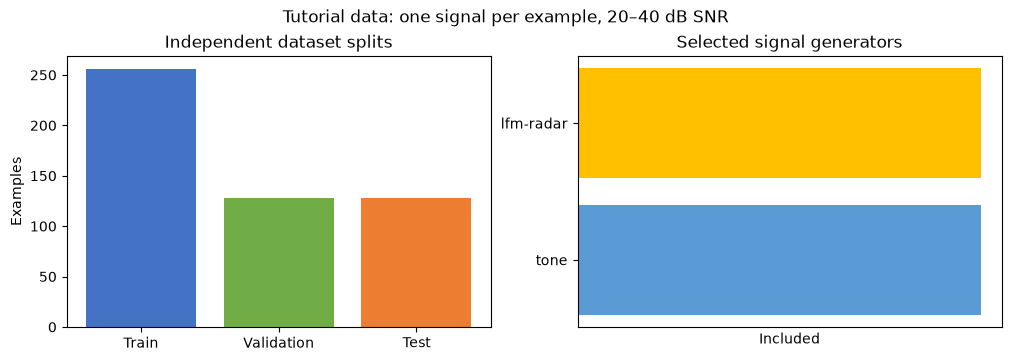

In [5]:
# A quick visual check of the experiment before generating any large files.
split_sizes = {'Train': train_cfg.dataset_length, 'Validation': val_cfg.dataset_length, 'Test': test_cfg.dataset_length}
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), constrained_layout=True)
axes[0].bar(list(split_sizes), list(split_sizes.values()), color=['#4472C4', '#70AD47', '#ED7D31'])
axes[0].set(title='Independent dataset splits', ylabel='Examples')
axes[1].barh(SIGNALS, [1] * len(SIGNALS), color=['#5B9BD5', '#FFC000'])
axes[1].set(title='Selected signal generators', xlabel='Included')
axes[1].set_xticks([])
fig.suptitle('Tutorial data: one signal per example, 20–40 dB SNR')
plt.show()

## 3. Generate, train, and evaluate through one API

> **Presenter (2:15–5:10):** `train_efficientnet_2d` is the useful high-level seam. Follow its arguments from left to right: three dataset contracts; a small, explicit hyperparameter dictionary; and separate homes for checkpoints, metrics, and generated examples. Internally it materializes reproducible static splits, applies TorchSig's `Spectrogram`, builds the repository's EfficientNet-B0, trains with cross-entropy, AdamW, and a warmup/cosine schedule, saves the best validation-F1 checkpoint, and evaluates the held-out test split. Static data are valuable because every epoch sees the same examples and a later run can reproduce evaluation. `overwrite=False` reuses those files; switch it on only when you intentionally change the data distribution. Validation data help select hyperparameters and checkpoints. Test data answer the final question after choices are frozen; repeatedly tuning against test accuracy turns the test set into another validation set. The return dictionary exposes the ordinary PyTorch model, Lightning wrapper, loaders, metric trackers, parameter count, and generated-data location, so the convenient API does not hide the experiment. The eight epochs and tiny splits are a smoke test.

For a real experiment, increase sample counts and epochs, add realistic impairments and SNR range, and use every class relevant to deployment. Full TorchSig datasets can require hundreds of GB.

In [6]:
params = {
    'batch_size': 16, 'max_epochs': 8, 'learning_rate': 3e-3,
    'weight_decay': 1e-5, 'drop_path': 0.0, 'drop_rate': 0.0,
    'label_smoothing': 0.0, 'normalize': False,
}

if RUN_TRAINING:
    result = train_efficientnet_2d(
        train_cfg, val_cfg, test_cfg, params,
        checkpoint_dir=RUNS / 'checkpoints',
        metrics_dir=RUNS / 'metrics',
        dataset_root=RUNS / 'datasets',
        overwrite=False, model_name='efficientnet_b0',
        signal_generators=SIGNALS, logger=False,
        accelerator='auto', devices='auto',
    )
    test_accuracy = result['test_metrics'].history['accuracy'][-1]
    print(f"parameters={result['num_params']:,}")
    print(f'test accuracy={test_accuracy:.2%}')
    print(f"data={result['data_info']['root']}")
else:
    print('Training skipped; set RUN_TRAINING=True to run this section.')

Training skipped; set RUN_TRAINING=True to run this section.


### Read the evaluation, not just the headline

> **Presenter (5:10–6:15):** Accuracy is a starting point: it answers how many examples were right, but not which signals failed or whether a majority class dominates. The returned `ClassifierMetricsTracker` also records precision, recall, F1, and confusion matrices, while CSV artifacts land under `metrics/`. A confusion matrix makes systematic substitutions visible—for example, confusing related PSK orders. Compare against chance and class-frequency baselines, inspect per-class recall, and stratify by SNR; a model that looks strong overall may collapse below zero dB. The explicit `evaluate_classifier` call shows that evaluation is reusable outside training. It puts the model in evaluation mode, disables gradient work, walks the test loader, and returns the same tracker shape. A high score on clean synthetic signals does not establish performance on recordings: sample rate, capture length, frontend filtering, normalization, class order, and channel conditions must match. Synthetic-to-real validation is a required experiment, not a deployment detail.

In [7]:
if RUN_TRAINING:
    print('metric fields:', sorted(result['test_metrics'].history))
    # Re-evaluate explicitly when testing a changed criterion or model.
    repeated = evaluate_classifier(
        result['model'], result['test_loader'], DEVICE, result['num_classes']
    )
    print(f"repeated accuracy={repeated.history['accuracy'][-1]:.2%}")

    tracked = result['metrics']
    epochs = range(1, len(tracked.train_losses) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), constrained_layout=True)
    axes[0].plot(epochs, tracked.train_losses, marker='o', label='train')
    axes[0].plot(epochs, tracked.val_losses, marker='o', label='validation')
    axes[0].set(title='Loss by epoch', xlabel='Epoch', ylabel='Cross-entropy loss')
    axes[1].plot(epochs, tracked.train_accuracies, marker='o', label='train')
    axes[1].plot(epochs, tracked.val_accuracies, marker='o', label='validation')
    axes[1].axhline(1 / len(SIGNALS), color='gray', linestyle='--', label='two-class chance')
    axes[1].set(title='Accuracy by epoch', xlabel='Epoch', ylabel='Accuracy', ylim=(0, 1.02))
    for axis in axes:
        axis.grid(alpha=0.25)
        axis.legend()
    plt.show()
else:
    print('Metric plots appear here after RUN_TRAINING=True completes.')

Metric plots appear here after RUN_TRAINING=True completes.


## 4. Inference from a saved checkpoint

> **Presenter (6:15–7:15):** Production inference is three operations: reproduce preprocessing, restore weights into the same architecture, then convert logits to probabilities and class indices. The helper discovers a checkpoint produced by the training API and evaluates a static TorchSig split. `efficientnet_inference` handles either a Lightning `.ckpt` or plain PyTorch state dictionary, removes Lightning's wrapper prefix when necessary, infers the output count from classifier weights, and rebuilds the requested EfficientNet variant with the saved training parameters. A successful weight load is also a useful architecture check. The returned scalar is dataset accuracy; for unlabeled operational data, use the same model forward pass and retain predicted index, confidence, and relevant metadata. Softmax confidence is not automatically calibrated probability. Keep the ordered class-name list and preprocessing configuration beside the checkpoint—an integer prediction has no meaning without them.

In [8]:
# Example after training; select the checkpoint you intend to deploy.
checkpoints = sorted((RUNS / 'checkpoints').glob('best-*.ckpt'))
checkpoint = checkpoints[-1] if checkpoints else None
static_test_root = RUNS / 'datasets' / 'efficientnet_tutorial' / 'test'
if checkpoint is not None:
    accuracy = efficientnet_inference(
        root=static_test_root, checkpoint_path=checkpoint,
        batch_size=16, num_workers=0, model_name='efficientnet_b0',
    )
else:
    print(f"Run training first; no checkpoint found under {RUNS / 'checkpoints'}.")


Test accuracy: 94.4526%


### Keep the trained checkpoint

Training writes the best validation-F1 checkpoint beneath `runs/v1_tutorial/checkpoints`. In Colab, run the next cell immediately after training to download it to your computer. Later, upload that `.ckpt` back to Colab and pass its path to `efficientnet_inference`. Outside Colab, the cell prints the local path; copy that file together with the model name, training parameters, preprocessing settings, and ordered class names.

The challenge uses a different, already-trained XCiT checkpoint. You can download it directly from the [TorchSig Models v1.0.0 release](https://github.com/TorchDSP/torchsig-models/releases/download/v1.0.0/xcit_narrowband_v1.0.0.ckpt), or let `solve_challenge.ipynb` download it automatically.

In [9]:
trained_checkpoints = sorted((RUNS / 'checkpoints').glob('best-*.ckpt'))
if not trained_checkpoints:
    print('No trained checkpoint yet. Set RUN_TRAINING=True and run the training cell first.')
else:
    trained_checkpoint = trained_checkpoints[-1]
    if IN_COLAB:
        from google.colab import files
        files.download(str(trained_checkpoint))
    else:
        print(f'Checkpoint ready to copy: {trained_checkpoint.resolve()}')

Checkpoint ready to copy: /home/amandapotts/git/torchsig-models/models_tutorial/runs/v1_tutorial/checkpoints/best-epoch=epoch=004-val_f1=val_f1=0.9759.ckpt


## 5. The challenge bridge: SigMF → XCiT → names

> **Presenter (7:15–9:25):** `solve_challenge.ipynb` changes the input and model, but not the inference pattern. SigMF stores raw complex samples in `.sigmf-data` and capture facts such as sample rate in `.sigmf-meta`. `StaticTorchSigDataset(..., file_handler_class=SigMFReader)` lets TorchSig treat those files like other datasets. Sorting the metadata paths establishes capture order; the dataloader must keep `shuffle=False`. XCiT does not accept NumPy complex values directly. It expects `[batch, 2, samples]`, so `ComplexTo2D`—or the equivalent stack below—places real I and imaginary Q in two float channels. Notice that this differs from EfficientNet's `[batch, 1, frequency, time]` spectrogram. `load_from_checkpoint` reconstructs the Lightning XCiT from saved hyperparameters and weights. Move model and tensor to the same device, call `eval()` so dropout and normalization behave deterministically, and use `torch.inference_mode()` to avoid gradient overhead. The model returns logits; softmax makes them easy to display, while `argmax` selects the same class with or without softmax. Map that integer through the checkpoint's exact ordered vocabulary. The released model has 57 outputs in the TorchSig 2.1.1 registry order; a newer TorchSig release may contain a different order, so importing today's registry can silently attach the wrong name to a correct index. Finally preserve capture order and concatenate each predicted name's first character.

These are the four challenge traps: sorting captures, matching I/Q shape, retaining historical class order, and using logits only after loading the checkpoint.

In [10]:
# Compact inference pattern used by solve_challenge.ipynb.
def classify_xcit(iq_samples: np.ndarray, checkpoint: Path, class_names: list[str]):
    model = XCiTClassifier.load_from_checkpoint(checkpoint, map_location=DEVICE)
    model.to(DEVICE).eval()
    # Equivalent to TorchSig ComplexTo2D: complex [B, N] -> real [B, 2, N].
    x = torch.from_numpy(np.stack((iq_samples.real, iq_samples.imag), axis=1))
    with torch.inference_mode():
        scores = model(x.to(DEVICE, dtype=torch.float32)).softmax(dim=1).cpu()
    confidence, index = scores.max(dim=1)
    names = [class_names[i] for i in index.tolist()]
    return names, confidence

# The solve notebook supplies CAPTURE_DIR, checkpoint download, and exact
# CLASS_NAMES_V211. Its data-loading core is:
# paths = sorted(CAPTURE_DIR.glob('capture_*.sigmf-meta'))
# captures = StaticTorchSigDataset(
#     root=CAPTURE_DIR, file_handler_class=SigMFReader, target_labels=[]
# )
# names, confidence = classify_xcit(iq_batch, CHECKPOINT, CLASS_NAMES_V211)
# answer = ''.join(name[0] for name in names).upper()

## 6. Takeaway

> **Presenter (9:25–10:00):** The reusable recipe is: define the signal distribution and disjoint splits; let TorchSig materialize deterministic data; train through the TorchSig Models API; evaluate beyond aggregate accuracy; and deploy with identical preprocessing, architecture, and label order. For the challenge, that same recipe collapses to sorted SigMF captures, two-channel IQ, the released XCiT checkpoint, historical labels, and first letters.